# Merged ATEM Inversion Results Plot

> This is notebook to review the inversion results generated by `tools/main_merged.py`.

## Workflow Overview

- Load merged inversion results (`*_inv_results_atem_full.pik`).
- Conduct binning process using `binning_normal(dx=50)`.
- Calculate active data ratio, misfit per iteration, and regularization metadata
- Interactive plotting function to show depth slice, difference map, L-curve

In [1]:
import dill
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from matplotlib.colors import LogNorm
from ipywidgets import VBox, interactive_output, widgets
from rich import print
from scipy.spatial import cKDTree as KDTree
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from types import SimpleNamespace
from cmcrameri import cm

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["figure.facecolor"] = "None"

In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"Current Working Directory: {os.getcwd()}")

sys.path.append("tools")
from tools import binning_normal

Current Working Directory: /Volumes/X31/01.Projects/atem

## 1. Load merged inversion restuls and binning configuration

In [3]:
areas = ["NW", "NE", "SE", "SW", "tielines"]
output_prefix = "merged"
dx = 50.0
istart_channel = 3
iend_channel = 25

criteria_rerr = 0.05
criteria_uncertainty = 0.05
bad_line_uncertainty = 0.30
floors_c = 0.05


def load_worst_lines(areas):
    worst_line = []
    for area in areas:
        worst_path = Path(f"./data/{area}_worst_50_smoothed_rmse.json")
        if not worst_path.exists():
            continue
        with worst_path.open("r") as f:
            payload = json.load(f)
        if payload and isinstance(payload[0], dict):
            worst_line.extend(str(value) for value in payload[0].values())
    return sorted(set(worst_line))


def rebuild_merged_binned_frames(areas, dx=50.0):
    all_values = []
    all_values_std = []
    all_soundings = []

    times = None
    n_turns = None
    dheader = None
    picker = None

    for area in areas:
        tmp = binning_normal(dx=dx, area=area)
        if times is None:
            times = tmp["times"]
            n_turns = tmp["n_turns"]
            dheader = tmp["dheader"]
            picker = tmp["picker"]

        all_values.extend(tmp["values"])
        all_values_std.extend(tmp["values_std"])
        all_soundings.extend(tmp["soundings"])

    if not all_values:
        raise ValueError("No binned data were reconstructed from the requested areas.")

    df_data_binned = pd.DataFrame(
        data=np.vstack(all_values),
        columns=["Line", "distance"] + picker[1:],
    )
    df_data_std_binned = pd.DataFrame(
        data=np.vstack(all_values_std),
        columns=["bheight"] + dheader,
    )

    for col in df_data_binned.columns:
        if col == "Line":
            df_data_binned[col] = df_data_binned[col].astype(str)
        else:
            df_data_binned[col] = pd.to_numeric(df_data_binned[col], errors="coerce")

    for col in df_data_std_binned.columns:
        df_data_std_binned[col] = pd.to_numeric(
            df_data_std_binned[col], errors="coerce"
        )

    return {
        "times": np.asarray(times, dtype=float),
        "soundings": [int(val) for val in all_soundings],
        "n_turns": float(n_turns),
        "dheader": list(dheader),
        "picker": list(picker),
        "df_data_binned": df_data_binned,
        "df_data_std_binned": df_data_std_binned,
    }

In [4]:
merged_data = rebuild_merged_binned_frames(areas=areas, dx=dx)
times = merged_data["times"]
soundings = merged_data["soundings"]
n_turns = merged_data["n_turns"]
dheader = merged_data["dheader"]
picker = merged_data["picker"]
df_data_binned = merged_data["df_data_binned"]
df_data_std_binned = merged_data["df_data_std_binned"]

result_path = Path(f"./data/merge/{output_prefix}_inv_results_atem_full.pik")
if not result_path.exists():
    raise FileNotFoundError(f"Merged inversion result not found: {result_path}")

with result_path.open("rb") as f:
    outDict = dill.load(f)

iter_keys = sorted(outDict.keys())
iterations = len(iter_keys)
first_key = iter_keys[0]

print(f"Areas: {areas}")
print(f"Result path: {result_path}")
print(f"Iterations: {iterations}")
print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Per-line sounding counts: {len(soundings):,} lines")
print(f"Stored keys at iteration {first_key}: {list(outDict[first_key].keys())}")
print(f"m shape: {np.asarray(outDict[first_key]['m']).shape}")
print(f"dpred shape: {np.asarray(outDict[first_key]['dpred']).shape}")

soundings_path = Path(f"./data/merge/{output_prefix}_soundings.json")
if soundings_path.exists():
    with soundings_path.open("r") as f:
        saved_soundings = [int(val) for val in json.load(f)]
    print(f"Saved soundings match reconstructed order: {saved_soundings == soundings}")
else:
    print(
        "No saved merged soundings JSON was found; using reconstructed ordering only."
    )

Areas: ['NW', 'NE', 'SE', 'SW', 'tielines']

Result path: data/merge/merged_inv_results_atem_full.pik

Iterations: 20

Binned soundings: 561,475

Per-line sounding counts: 513 lines

Stored keys at iteration 1: ['iter', 'beta', 'phi_d', 'phi_m', 'f', 'm', 'dpred', 'SparseSmallness.irls_threshold',
'SparseSmallness.norm', 'r LaterallyConstrainedSmoothness.irls_threshold', 'r LaterallyConstrainedSmoothness.norm',
'z LaterallyConstrainedSmoothness.irls_threshold', 'z LaterallyConstrainedSmoothness.norm']

m shape: (12352450,)

dpred shape: (12352450,)

Saved soundings match reconstructed order: True

## 2. Uncertainty mask, Interpolated map for depth slice

In [5]:
worst_line = load_worst_lines(areas)
bad_line_id = df_data_binned["Line"].astype(str).isin(worst_line).values

data_ = df_data_binned[dheader].values.astype(float)
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
data_rerr = (
    df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)
).astype(float)
cut_off = (data_rerr > criteria_rerr) * (channel_id >= 0)
bad_line_mask = np.repeat(bad_line_id[:, None], data_.shape[1], axis=1)

floors = 5e-9 / (df_data_binned["TranPeak"].values * n_turns) * floors_c
dobs = df_data_binned[dheader].values.flatten().astype(float)
std = df_data_std_binned[dheader].values.flatten().astype(float)
dobs_std = np.abs(dobs) * criteria_uncertainty
dobs_std[std > dobs_std] = std[std > dobs_std]
dobs_std[bad_line_mask.flatten()] = (
    np.abs(dobs[bad_line_mask.flatten()]) * bad_line_uncertainty
)
dobs_std[cut_off.flatten()] = np.inf
dobs_std += np.repeat(floors, iend_channel - istart_channel)

active_data_count = int(dobs.shape[0] - cut_off.sum())
print(
    f"Active data percentage = {active_data_count:,}/{len(dobs):,} = {active_data_count / len(dobs) * 100:,.1f}%"
)
print(f"Worst-line entries used for inflated uncertainty: {len(worst_line):,}")

topography = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values.astype(float)
source_heights = df_data_binned["bheight"].values.astype(float)
thickness = get_vertical_discretization(21, 2, 1.17)
hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

input_data_dict = {
    "topography": topography,
    "source_heights": source_heights,
    "thickness": thickness,
    "times": times,
}
inp = SimpleNamespace(**input_data_dict)

line_no = list(df_data_binned["Line"].astype(str).unique())
line_name_values = [str(val) for val in line_no]
n_sounding = len(df_data_binned)
n_layer = len(hz)
n_time = len(times)

model_size = np.asarray(outDict[first_key]["m"], dtype=float).size
expected_model_size = n_sounding * n_layer
if model_size != expected_model_size:
    raise ValueError(f"Model size mismatch: {model_size} != {expected_model_size}")

observed_matrix = np.asarray(dobs, dtype=float).reshape((-1, n_time))
phi_d = np.array([outDict[i]["phi_d"] for i in iter_keys], dtype=float)
phi_m = np.array([outDict[i]["phi_m"] for i in iter_keys], dtype=float)
no_of_data_points = active_data_count
chi_squared = phi_d / no_of_data_points


def get_iteration_summary(i_iteration):
    iteration_dict = outDict[i_iteration]
    m_iter = np.asarray(iteration_dict["m"], dtype=float)
    dpred_iter = np.asarray(iteration_dict["dpred"], dtype=float).reshape((-1, n_time))
    rho_layers = (1.0 / np.exp(m_iter)).reshape((n_sounding, n_layer))
    return {
        "m": m_iter,
        "dpred": dpred_iter,
        "rho_layers": rho_layers,
        "phi_d": float(iteration_dict["phi_d"]),
        "phi_m": float(iteration_dict["phi_m"]),
    }


line_slices = {}
distance_by_line = {}
offset = 0
for line_name, count in zip(line_name_values, soundings):
    next_offset = offset + int(count)
    line_slice = slice(offset, next_offset)
    line_slices[str(line_name)] = line_slice
    distance_by_line[str(line_name)] = pd.to_numeric(
        df_data_binned.iloc[line_slice]["distance"],
        errors="coerce",
    ).to_numpy(dtype=float)
    offset = next_offset

if offset != n_sounding:
    raise ValueError(f"Sounding count mismatch: {offset} != {n_sounding}")

map_dx = 100.0
map_dy = 100.0
x_pad = 1000.0
y_pad = 1000.0
k_nearest_points = 100
max_distance = 500.0
idw_power = 0.0

xy_model = inp.topography[:, :2]
xmin = np.nanmin(xy_model[:, 0]) - x_pad
xmax = np.nanmax(xy_model[:, 0]) + x_pad
ymin = np.nanmin(xy_model[:, 1]) - y_pad
ymax = np.nanmax(xy_model[:, 1]) + y_pad

nx = int(np.floor((xmax - xmin) / map_dx)) + 1
ny = int(np.floor((ymax - ymin) / map_dy)) + 1
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

map_tree = KDTree(xy_model)
k_idw = min(int(k_nearest_points), len(xy_model))
distances_idw, indices_idw = map_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()], k=k_idw
)
if k_idw == 1:
    distances_idw = distances_idw[:, None]
    indices_idw = indices_idw[:, None]

idw_epsilon = min(map_dx, map_dy)
idw_weights = 1.0 / ((distances_idw + idw_epsilon) ** idw_power)
nearest_distance, _ = map_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance


def interpolate_to_map(values):
    values = np.asarray(values, dtype=float)
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(
        idw_weights, axis=1
    )
    values_grid[mask_outside_data] = np.nan
    return values_grid.reshape(X_map.shape)


print(f"n_sounding={n_sounding:,}, n_layer={n_layer}, n_time={n_time}")
print(f"Map grid: {X_map.shape} | k_idw={k_idw}")
print(f"chi-squared normalization uses active data count: {no_of_data_points:,}")

Active data percentage = 9,318,328/12,352,450 = 75.4%

Worst-line entries used for inflated uncertainty: 205

>> Depth from the surface to the base of the bottom layer is 306.3m


n_sounding=561,475, n_layer=22, n_time=22

Map grid: (2053, 1511) | k_idw=100

chi-squared normalization uses active data count: 9,318,328

## 3. Interactive depth slice 

In [6]:
def plot_combined_map_and_line(i_iteration, line_name, i_depth):
    summary = get_iteration_summary(i_iteration)
    rho_layers = summary["rho_layers"]
    dpred_matrix = summary["dpred"]

    values_grid = interpolate_to_map(rho_layers[:, i_depth])
    line_slice = line_slices[str(line_name)]
    selected_line = df_data_binned.iloc[line_slice].copy()
    if selected_line.empty:
        raise ValueError(f"No data found for line {line_name}")

    distances = distance_by_line[str(line_name)]
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    out = ax1.pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    # ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="white",
        linewidth=2.0,
    )
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="black",
        linewidth=0.8,
    )
    ax1.scatter(
        selected_line["x_wgs84"].iloc[0],
        selected_line["y_wgs84"].iloc[0],
        s=30,
        color="white",
        edgecolor="black",
        zorder=5,
    )
    cb = plt.colorbar(out, ax=ax1, orientation="vertical")
    cb.set_label("Resistivity (ohm-m)")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    ax1.set_aspect(1)
    ax1.set_title(
        f"Iteration {i_iteration}, Line {line_name}, Depth {depth_centers[i_depth]:.1f} m"
    )
    ax1.grid(True, alpha=0.15)

    dpred_line = -np.asarray(dpred_matrix[line_slice, :], dtype=float)[sort_idx, :]
    dobs_line = -np.asarray(observed_matrix[line_slice, :], dtype=float)[sort_idx, :]
    for i_time in range(n_time):
        ax2.plot(
            distances_sorted,
            dpred_line[:, i_time],
            "-",
            linewidth=1.0,
            alpha=0.7,
            label=f"T{i_time}" if i_time < 6 else None,
        )
        ax2.plot(
            distances_sorted,
            dobs_line[:, i_time],
            "k--",
            linewidth=0.8,
            alpha=0.35,
        )

    ax2.set_yscale("log")
    ax2.set_xlabel("Distance along line (m)")
    ax2.set_ylabel("|dB/dt| (V/A/m²)")
    ax2.grid(False)
    ax2.set_title(f"Iteration {i_iteration}, Line {line_name}")
    ax2.legend(ncol=2, fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


iter_depth_slider = widgets.IntSlider(
    min=min(iter_keys),
    max=max(iter_keys),
    step=1,
    value=min(iter_keys),
    description="Iteration:",
    continuous_update=False,
)
line_slider = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
)
depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

combined_output = interactive_output(
    plot_combined_map_and_line,
    {
        "i_iteration": iter_depth_slider,
        "line_name": line_slider,
        "i_depth": depth_slider,
    },
)

VBox([iter_depth_slider, line_slider, depth_slider, combined_output])

## 4. Interactive difference map

`Δρ = ρ_i - ρ_{i-1}`

In [7]:
def plot_iteration_resistivity_comparison(i_iteration, i_depth):
    prev_summary = get_iteration_summary(i_iteration - 1)
    next_summary = get_iteration_summary(i_iteration)

    values_iter_grid = interpolate_to_map(prev_summary["rho_layers"][:, i_depth])
    values_next_grid = interpolate_to_map(next_summary["rho_layers"][:, i_depth])
    values_diff_grid = values_next_grid - values_iter_grid

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    out1 = ax1.pcolormesh(
        x_map,
        y_map,
        values_iter_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.set_aspect(1)
    ax1.set_title(f"Iteration {i_iteration - 1}, Depth {depth_centers[i_depth]:.1f} m")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    plt.colorbar(out1, ax=ax1, label="Resistivity (Ω·m)")

    out2 = ax2.pcolormesh(
        x_map,
        y_map,
        values_next_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    ax2.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax2.set_aspect(1)
    ax2.set_title(f"Iteration {i_iteration}, Depth {depth_centers[i_depth]:.1f} m")
    ax2.set_xlabel("x_wgs84")
    ax2.set_ylabel("y_wgs84")
    plt.colorbar(out2, ax=ax2, label="Resistivity (Ω·m)")

    vmax_diff = np.nanmax(np.abs(values_diff_grid))
    if not np.isfinite(vmax_diff) or vmax_diff == 0:
        vmax_diff = 1.0
    out3 = ax3.pcolormesh(
        x_map,
        y_map,
        values_diff_grid,
        cmap="RdBu_r",
        vmin=-vmax_diff,
        vmax=vmax_diff,
        shading="auto",
    )
    ax3.set_aspect(1)
    ax3.set_title(f"Difference (Iter {i_iteration} - Iter {i_iteration - 1})")
    ax3.set_xlabel("x_wgs84")
    ax3.set_ylabel("y_wgs84")
    plt.colorbar(out3, ax=ax3, label="ΔResistivity (Ω·m)")

    plt.tight_layout()
    plt.show()


iter_slider = widgets.IntSlider(
    min=min(iter_keys) + 1,
    max=max(iter_keys),
    step=1,
    value=min(iter_keys) + 1,
    description="Iteration:",
    continuous_update=False,
)

iter_depth_slider_comp = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

iter_comparison_output = interactive_output(
    plot_iteration_resistivity_comparison,
    {"i_iteration": iter_slider, "i_depth": iter_depth_slider_comp},
)

VBox([iter_slider, iter_depth_slider_comp, iter_comparison_output])

## 5. Interactive XZ cross section 

In [8]:
def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def _moving_average_nan_1d(arr, window):
    if window <= 1:
        return arr
    kernel = np.ones(window, dtype=float)
    valid = np.isfinite(arr).astype(float)
    filled = np.where(np.isfinite(arr), arr, 0.0)
    num = np.convolve(filled, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.full_like(arr, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out


def _smooth_section_2d(section, window_x=5, window_z=1):
    smoothed = section.copy().astype(float)
    if window_x > 1:
        for i in range(smoothed.shape[0]):
            smoothed[i, :] = _moving_average_nan_1d(smoothed[i, :], window_x)
    if window_z > 1:
        for j in range(smoothed.shape[1]):
            smoothed[:, j] = _moving_average_nan_1d(smoothed[:, j], window_z)
    return smoothed


def plot_line_xz_section(
    i_iteration,
    line_name,
    apply_smoothing=False,
    smooth_x=5,
    smooth_z=1,
):
    line_slice = line_slices[str(line_name)]
    summary = get_iteration_summary(i_iteration)
    rho_layers = summary["rho_layers"]
    dpred_matrix = summary["dpred"]

    line_rho = rho_layers[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho_sorted = np.asarray(line_rho[sort_idx, :], dtype=float)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    # fig, (ax, ax_data, ax_loc) = plt.subplots(
    #     1,
    #     3,
    #     figsize=(25, 6),
    #     gridspec_kw={"width_ratios": [6, 3, 3]},
    # )
    fig, (ax, ax_loc) = plt.subplots(
        1,
        2,
        figsize=(20, 5),
        gridspec_kw={"width_ratios": [6, 1]},
    )

    section = line_rho_sorted.T
    if apply_smoothing:
        section = _smooth_section_2d(
            section, window_x=int(smooth_x), window_z=int(smooth_z)
        )

    pcm = ax.pcolormesh(
        X_edges,
        Z_edges,
        section,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    cbar = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        pad=0.14,
        fraction=0.08,
    )
    ax.plot(X_edges[0,:], Z_edges[0,:] - 50, "k.", markersize=0.3)
    cbar.set_label("Resistivity (ohm-m)")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Distance along line (m)")
    ax.set_ylabel("Elevation (m)")
    smooth_tag = (
        f" | smooth x={int(smooth_x)}, z={int(smooth_z)}" if apply_smoothing else ""
    )
    ax.set_title(
        f"Terrain-following XZ Section | Iteration {i_iteration}, Line {line_name}{smooth_tag}"
    )
    ax.grid(False)

    x_all = pd.to_numeric(df_data_binned["x_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    y_all = pd.to_numeric(df_data_binned["y_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    x_line = x_all[line_slice][sort_idx]
    y_line = y_all[line_slice][sort_idx]

    all_mask = np.isfinite(x_all) & np.isfinite(y_all)
    line_mask = np.isfinite(x_line) & np.isfinite(y_line)

    if np.any(all_mask):
        ax_loc.scatter(
            x_all[all_mask],
            y_all[all_mask],
            s=2,
            c="lightgray",
            edgecolors="none",
            alpha=0.7,
        )

    if np.any(line_mask):
        ax_loc.plot(
            x_line[line_mask],
            y_line[line_mask],
            color="crimson",
            linewidth=1.6,
            zorder=3,
        )
        ax_loc.scatter(
            x_line[line_mask][0],
            y_line[line_mask][0],
            s=26,
            c="white",
            edgecolors="black",
            zorder=4,
        )
    else:
        ax_loc.text(
            0.5,
            0.5,
            "No valid XY",
            ha="center",
            va="center",
            transform=ax_loc.transAxes,
        )

    ax_loc.set_aspect(1)
    ax_loc.set_title(f"Locator\nLine {line_name}")
    ax_loc.set_xlabel("x_wgs84")
    ax_loc.set_ylabel("y_wgs84")
    ax_loc.grid(False)

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

smooth_toggle = widgets.Checkbox(
    value=False,
    description="Apply smoothing",
)

smooth_x_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=31,
    step=2,
    description="Smooth X:",
    continuous_update=False,
)

smooth_z_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=9,
    step=2,
    description="Smooth Z:",
    continuous_update=False,
)

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration": iter_slider_xz,
        "line_name": line_slider_xz,
        "apply_smoothing": smooth_toggle,
        "smooth_x": smooth_x_slider,
        "smooth_z": smooth_z_slider,
    },
)

VBox(
    [
        iter_slider_xz,
        line_slider_xz,
        smooth_toggle,
        smooth_x_slider,
        smooth_z_slider,
        xz_output,
    ]
)

In [ ]:
def build_area_line_name_map(areas, line_name_values, dx):
    area_line_names = {}
    line_counts = []
    for area in areas:
        payload = binning_normal(dx=dx, area=area)
        line_counts.append(len(payload.get("soundings", [])))

    offset = 0
    for area, count in zip(areas, line_counts):
        next_offset = offset + int(count)
        area_line_names[str(area)] = list(line_name_values[offset:next_offset])
        offset = next_offset

    if offset != len(line_name_values):
        remainder = line_name_values[offset:]
        if len(areas) > 0 and len(remainder) > 0:
            last_area = str(areas[-1])
            area_line_names[last_area] = area_line_names.get(last_area, []) + list(
                remainder
            )

    return area_line_names


def interpolate_area_to_map(
    values,
    mask,
    x_grid,
    y_grid,
    max_distance=500.0,
    k_nearest_points=80,
    idw_power=1.0,
    idw_epsilon=100.0,
):
    values = np.asarray(values, dtype=float)
    mask = np.asarray(mask, dtype=bool)

    xy_area = xy_model[mask]
    val_area = values[mask]

    valid = np.isfinite(xy_area).all(axis=1) & np.isfinite(val_area)
    xy_area = xy_area[valid]
    val_area = val_area[valid]

    if xy_area.shape[0] < 3:
        return np.full((len(y_grid), len(x_grid)), np.nan, dtype=float), xy_area

    Xg, Yg = np.meshgrid(x_grid, y_grid)
    query_xy = np.c_[Xg.ravel(), Yg.ravel()]

    tree = KDTree(xy_area)
    k = min(int(k_nearest_points), xy_area.shape[0])
    distances, indices = tree.query(query_xy, k=k)
    if k == 1:
        distances = distances[:, None]
        indices = indices[:, None]

    weights = 1.0 / ((distances + idw_epsilon) ** idw_power)
    val_grid = np.sum(weights * val_area[indices], axis=1) / np.sum(weights, axis=1)

    nearest_dist, _ = tree.query(query_xy, k=1)
    val_grid[nearest_dist > max_distance] = np.nan
    return val_grid.reshape(Xg.shape), xy_area


area_line_name_map = build_area_line_name_map(areas, line_name_values, dx)
all_area_names = [str(a) for a in areas]


def _build_local_grid(area_xy, dx_local=100.0, dy_local=100.0, pad=300.0):
    xmin_local = np.nanmin(area_xy[:, 0]) - pad
    xmax_local = np.nanmax(area_xy[:, 0]) + pad
    ymin_local = np.nanmin(area_xy[:, 1]) - pad
    ymax_local = np.nanmax(area_xy[:, 1]) + pad

    nx_local = max(2, int(np.floor((xmax_local - xmin_local) / dx_local)) + 1)
    ny_local = max(2, int(np.floor((ymax_local - ymin_local) / dy_local)) + 1)
    x_local = np.arange(nx_local) * dx_local + xmin_local
    y_local = np.arange(ny_local) * dy_local + ymin_local
    return x_local, y_local


def plot_area_depth_section(i_iteration, i_depth, area_name):
    summary = get_iteration_summary(i_iteration)
    rho_layers = summary["rho_layers"]
    depth_values = rho_layers[:, i_depth]

    line_names = area_line_name_map.get(str(area_name), [])
    mask = df_data_binned["Line"].astype(str).isin(line_names).to_numpy(dtype=bool)

    area_xy_raw = xy_model[mask]
    area_xy_valid_mask = np.isfinite(area_xy_raw).all(axis=1)
    area_xy = area_xy_raw[area_xy_valid_mask]
    if area_xy.shape[0] < 3:
        raise ValueError(f"Not enough valid XY points for area: {area_name}")

    x_local, y_local = _build_local_grid(area_xy, dx_local=map_dx, dy_local=map_dy, pad=300.0)
    area_grid, area_xy_used = interpolate_area_to_map(
        values=depth_values,
        mask=mask,
        x_grid=x_local,
        y_grid=y_local,
        max_distance=max_distance,
        k_nearest_points=min(k_nearest_points, 80),
        idw_power=1.0,
        idw_epsilon=min(map_dx, map_dy),
    )

    vals = depth_values[mask]
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        raise ValueError(f"No finite positive resistivity values for area: {area_name}")

    # vmin = np.nanpercentile(vals, 5)
    # vmax = np.nanpercentile(vals, 95)
    # if not np.isfinite(vmin) or vmin <= 0:
    #     vmin = np.nanmin(vals[vals > 0])
    # if not np.isfinite(vmax) or vmax <= vmin:
    #     vmax = max(vmin * 1.05, np.nanmax(vals))
    vmin = 8
    vmax = 60

    fig, ax = plt.subplots(1, 1, figsize=(8, 7), constrained_layout=True)

    pcm = ax.pcolormesh(
        x_local,
        y_local,
        area_grid,
        cmap="turbo",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        shading="auto",
    )
    fig.colorbar(pcm, ax=ax, orientation="vertical", label="Resistivity (ohm-m)")

    if area_xy_used.size > 0:
        ax.plot(area_xy_used[:, 0], area_xy_used[:, 1], "k,", alpha=0.12)

    ax.set_xlim(np.nanmin(x_local), np.nanmax(x_local))
    ax.set_ylim(np.nanmin(y_local), np.nanmax(y_local))
    ax.set_aspect(1)
    ax.set_xlabel("x_wgs84")
    ax.set_ylabel("y_wgs84")
    ax.set_title(
        f"Area {area_name} | Iteration {i_iteration} | Depth {depth_centers[i_depth]:.1f} m"
    )
    ax.grid(False)
    plt.show()


area_mode_dropdown = widgets.Dropdown(
    options=all_area_names,
    value=all_area_names[0],
    description="Area:",
)

area_iter_slider = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

area_depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

area_output = interactive_output(
    plot_area_depth_section,
    {
        "i_iteration": area_iter_slider,
        "i_depth": area_depth_slider,
        "area_name": area_mode_dropdown,
    },
)

display(
    VBox(
        [
            area_iter_slider,
            area_depth_slider,
            area_mode_dropdown,
            area_output,
        ]
    )
)

## 6. Gradient criteria, \(\chi^2\), L-curve

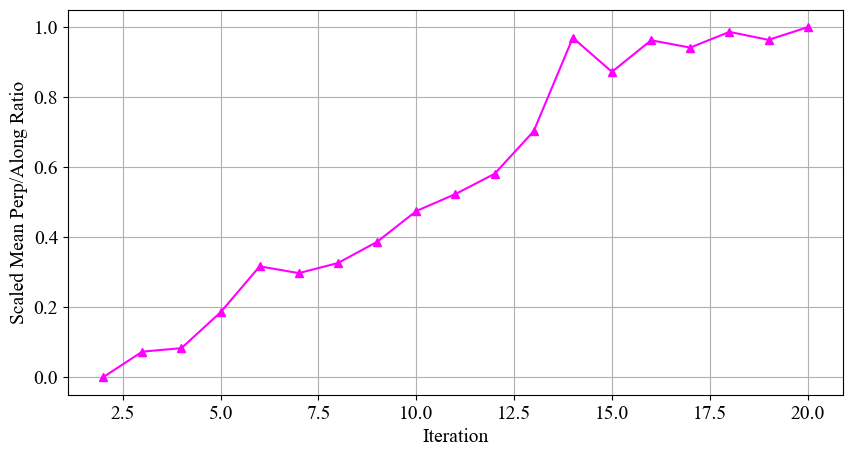

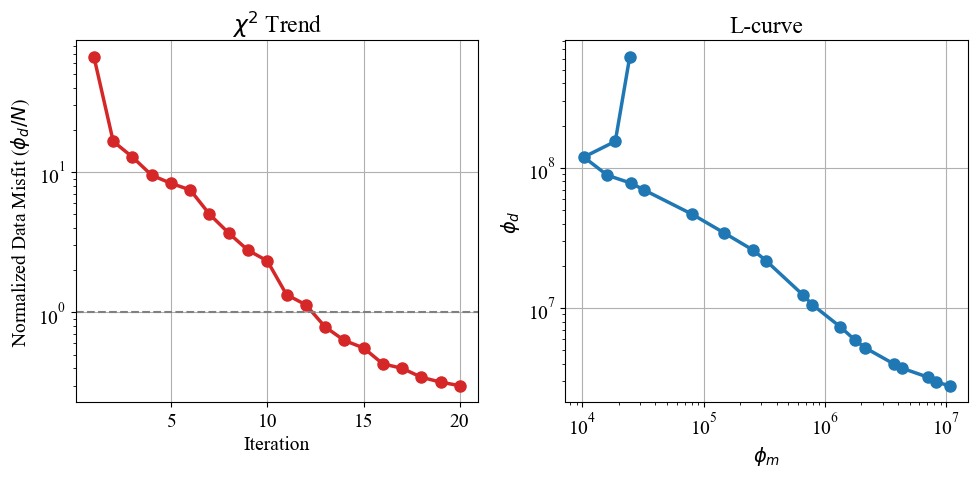

,iteration,phi_d,phi_m,chi_squared,mean_ratio_C5
0,1,6.188092e+08,2.464897e+04,66.407755,NaN
1,2,1.545239e+08,1.874274e+04,16.582789,-0.432814
2,3,1.193738e+08,1.030318e+04,12.810646,-0.389969
3,4,8.853929e+07,1.611796e+04,9.501629,-0.384156
4,5,7.757458e+07,2.547276e+04,8.324946,-0.324160
5,6,6.958955e+07,3.228091e+04,7.468030,-0.247152
6,7,4.667953e+07,8.064886e+04,5.009432,-0.258544
7,8,3.424877e+07,1.488609e+05,3.675420,-0.241617
8,9,2.582977e+07,2.575150e+05,2.771932,-0.206136
9,10,2.171176e+07,3.288153e+05,2.330006,-0.154618


In [10]:
def min_max_scaler(arr):
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    if max_val - min_val == 0:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)


def _reference_unit_vectors():
    first_line_slice = next(iter(line_slices.values()))
    first_line_xy = xy_model[first_line_slice]
    finite_mask = np.isfinite(first_line_xy).all(axis=1)
    first_line_xy = first_line_xy[finite_mask]
    if first_line_xy.shape[0] < 2:
        raise ValueError(
            "Not enough finite points to define a reference line direction."
        )
    first_line_vec = first_line_xy[-1] - first_line_xy[0]
    first_line_angle = np.arctan2(first_line_vec[1], first_line_vec[0])
    along_u = np.array([np.cos(first_line_angle), np.sin(first_line_angle)])
    perp_u = np.array([-np.sin(first_line_angle), np.cos(first_line_angle)])
    return along_u, perp_u


def compute_line_directional_ratios_by_depth(i_iteration, opt="C5"):
    prev_summary = get_iteration_summary(i_iteration - 1)
    next_summary = get_iteration_summary(i_iteration)
    along_u, perp_u = _reference_unit_vectors()

    depth_ratios = []
    for i_depth in range(n_layer):
        values_diff = (
            next_summary["rho_layers"][:, i_depth]
            - prev_summary["rho_layers"][:, i_depth]
        )
        values_diff_grid = interpolate_to_map(values_diff)
        dy_grid, dx_grid = np.gradient(values_diff_grid, y_map, x_map)

        if opt == "C1":
            along_proj = np.nanmean(np.abs(dx_grid * along_u[0] + dy_grid * along_u[1]))
            perp_proj = np.nanmean(np.abs(dx_grid * perp_u[0] + dy_grid * perp_u[1]))
            depth_ratios.append(perp_proj / along_proj)

        if opt == "C2":
            along_proj = np.sqrt(
                np.nanmean((dx_grid * along_u[0] + dy_grid * along_u[1]) ** 2)
            )
            perp_proj = np.sqrt(
                np.nanmean((dx_grid * perp_u[0] + dy_grid * perp_u[1]) ** 2)
            )
            depth_ratios.append(perp_proj / along_proj)

        if opt == "C3":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[np.abs(along_proj) <= 1e-10] = np.inf
            depth_ratios.append(np.nanmean(np.abs(perp_proj / along_proj)))

        if opt == "C4":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[np.abs(along_proj) <= 1e-10] = np.inf
            depth_ratios.append(np.sqrt(np.nanmean((perp_proj / along_proj) ** 2)))

        if opt == "C5":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            depth_ratios.append(
                np.nanmean(
                    (-(along_proj**2) + (perp_proj**2))
                    / ((along_proj**2) + (perp_proj**2) + 1e-10)
                )
            )

    return np.array(depth_ratios, dtype=float)


ratio_matrix_C5 = np.vstack(
    [
        compute_line_directional_ratios_by_depth(i_iteration=i, opt="C5")
        for i in iter_keys[1:]
    ]
)


def plot_ratio_by_depth(depth_index=0):
    iters = np.array(iter_keys[1:])
    ratio_values = ratio_matrix_C5[:, depth_index]
    ymin = np.nanmin(ratio_values)
    ymax = np.nanmax(ratio_values)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        ymin, ymax = -1.0, 1.0

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.plot(
        iters, ratio_values, marker="o", color="tab:blue", linewidth=2.5, markersize=8
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Perp/Along Ratio")
    ax.set_title(
        f"Depth {depth_centers[depth_index]:.1f} m: Perp/Along Ratio by Iteration"
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylim(ymin * 1.1, ymax * 1.1)
    plt.show()


depth_ratio_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

ratio_output = interactive_output(
    plot_ratio_by_depth,
    {"depth_index": depth_ratio_slider},
)

display(VBox([depth_ratio_slider, ratio_output]))

plt.figure(figsize=(10, 5))
plt.plot(
    np.array(iter_keys[1:]),
    min_max_scaler(np.nanmean(ratio_matrix_C5, axis=1)),
    c="magenta",
    marker="^",
)
plt.xlabel("Iteration")
plt.ylabel("Scaled Mean Perp/Along Ratio")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(
    iter_keys, chi_squared, marker="o", color="tab:red", linewidth=2.5, markersize=8
)
plt.axhline(
    y=1.0, color="gray", linestyle="--", linewidth=1.5, label="Target $\\chi^2$"
)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Normalized Data Misfit ($\\phi_d / N$)")
plt.title("$\\chi^2$ Trend")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(phi_m, phi_d, marker="o", color="tab:blue", linewidth=2.5, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.title("L-curve")
plt.xlabel("$\\phi_m$")
plt.ylabel("$\\phi_d$")
plt.grid()
plt.tight_layout()
plt.show()

output_dir = Path("./outputs/merged_inversion_results")
output_dir.mkdir(parents=True, exist_ok=True)

summary_frame = pd.DataFrame(
    {
        "iteration": iter_keys,
        "phi_d": phi_d,
        "phi_m": phi_m,
        "chi_squared": chi_squared,
    }
)
summary_frame["mean_ratio_C5"] = np.r_[np.nan, np.nanmean(ratio_matrix_C5, axis=1)]
summary_frame


In [11]:
# def export_iteration_resistivity_csv(
#     i_iteration=14,
#     directory=None,
#     prefix=None,
#     long_format=False,
# ):
#     if i_iteration not in iter_keys:
#         raise ValueError(
#             f"Iteration {i_iteration} is not available. Available iterations: {iter_keys}"
#         )

#     summary = get_iteration_summary(i_iteration)
#     rho_layers = np.asarray(summary["rho_layers"], dtype=float)

#     meta_cols = ["Line", "distance", "x_wgs84", "y_wgs84", "dtm", "bheight"]
#     available_meta_cols = [col for col in meta_cols if col in df_data_binned.columns]
#     out_df = df_data_binned[available_meta_cols].copy()

#     if rho_layers.shape[0] != len(out_df):
#         raise ValueError(
#             f"Row mismatch: rho_layers={rho_layers.shape[0]}, df_data_binned={len(out_df)}"
#         )

#     depth_labels = [f"rho_{depth_centers[i]:.2f}m" for i in range(rho_layers.shape[1])]
#     rho_df = pd.DataFrame(rho_layers, columns=depth_labels, index=out_df.index)
#     out_df = pd.concat([out_df, rho_df], axis=1)

#     if long_format:
#         out_df = out_df.melt(
#             id_vars=available_meta_cols,
#             var_name="depth_label",
#             value_name="resistivity_ohm_m",
#         )

#     if directory is None:
#         directory = globals().get("output_dir", Path("./outputs/merged_inversion_results"))
#     if prefix is None:
#         prefix = globals().get("output_prefix", "merged")

#     directory = Path(directory)
#     directory.mkdir(parents=True, exist_ok=True)
#     format_tag = "long" if long_format else "wide"
#     csv_path = directory / f"{prefix}_iteration_{i_iteration:02d}_resistivity_{format_tag}.csv"
#     out_df.to_csv(csv_path, index=False)

#     print(f"Saved iteration resistivity CSV to {csv_path}")
#     print(f"shape={out_df.shape}")
#     return csv_path


# # Export iteration 14 in wide format (one row per sounding, depth-wise resistivity columns)
# iter14_csv_path = export_iteration_resistivity_csv(i_iteration=14, long_format=False)
# iter14_csv_path